In [2]:
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt

In [5]:


# Connect to the NFL database
db_path = Path('../data/nfl.duckdb')
conn = duckdb.connect(str(db_path))

# Query team_offense table into dataframe
df = conn.execute('SELECT * FROM team_offense where len(posteam) > 1').df()
print(f"Team offense data shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Team offense data shape: (829, 5)

First 5 rows:


,posteam,season,median_off_epa,mean_off_epa,offense_rating
0,DEN,1999,-0.224647,-0.047676,bad
1,CLE,1999,-0.324529,-0.128422,bad
2,IND,2000,-0.103534,0.111361,good
3,CHI,2001,-0.253548,-0.078087,bad
4,PHI,2001,-0.249879,-0.024855,bad


In [10]:
df[df.season==2024].sort_values('mean_off_epa',ascending=False)

,posteam,season,median_off_epa,mean_off_epa,offense_rating
423,BAL,2024,0.009454,0.219023,good
380,BUF,2024,-0.055163,0.189500,good
381,DET,2024,0.021566,0.164525,good
584,WAS,2024,-0.056278,0.132213,good
121,TB,2024,-0.011643,0.129193,good
676,PHI,2024,-0.159092,0.118785,good
162,CIN,2024,-0.065622,0.090178,good
207,GB,2024,-0.108118,0.070572,good
416,SF,2024,-0.111596,0.068745,good
460,ARI,2024,-0.079566,0.067081,good


In [107]:
#this just gets the offense defense matchups
df_games = conn.execute('SELECT * FROM games').df()

df_games.head()

,game_id,posteam,defteam,season,week,season_type,avg_off_epa,avg_def_epa
0,1999_01_PIT_CLE,CLE,PIT,1999,1,REG,-0.536443,0.536443
1,1999_02_GB_DET,DET,GB,1999,2,REG,-0.021170,0.021170
2,1999_03_SF_ARI,ARI,SF,1999,3,REG,-0.104655,0.104655
3,1999_05_DEN_OAK,LV,DEN,1999,5,REG,-0.125159,0.125159
4,1999_06_SEA_SD,LAC,SEA,1999,6,REG,-0.115574,0.115574


In [58]:
df_def = conn.execute('SELECT * FROM team_defense where len(defteam) > 1').df()
print(f"Team defense data shape: {team_offense_df.shape}")
print("\nFirst 5 rows:")
df_def.head()

Team defense data shape: (830, 5)

First 5 rows:


,defteam,season,median_def_epa,mean_def_epa,defense_rating
0,DEN,1999,0.258707,0.071805,good
1,CLE,1999,0.063538,-0.095840,bad
2,IND,2000,0.206048,0.000869,average
3,CHI,2001,0.256206,0.136890,good
4,PHI,2001,0.259765,0.123583,good


In [61]:
last5_def = df_def[df_def.season >= 2020]
print('bottom 25 percent mean offense epa: ',last5_def.mean_def_epa.quantile(.25))
print('50 percent mean offense epa: ',last5_def.mean_def_epa.quantile(.5))
print('top 25 percent mean offense epa: ',last5_def.mean_def_epa.quantile(.75))

bottom 25 percent mean offense epa:  -0.04153502551720114
50 percent mean offense epa:  -0.005997623522948533
top 25 percent mean offense epa:  0.042534670484200565


In [ ]:
last5_def = df[df.season >= 2020]
print('bottom 25 percent mean offense epa: ',last5_off.mean_off_epa.quantile(.25))
print('50 percent mean offense epa: ',last5_off.mean_off_epa.quantile(.5))
print('top 25 percent mean offense epa: ',last5_off.mean_off_epa.quantile(.75))

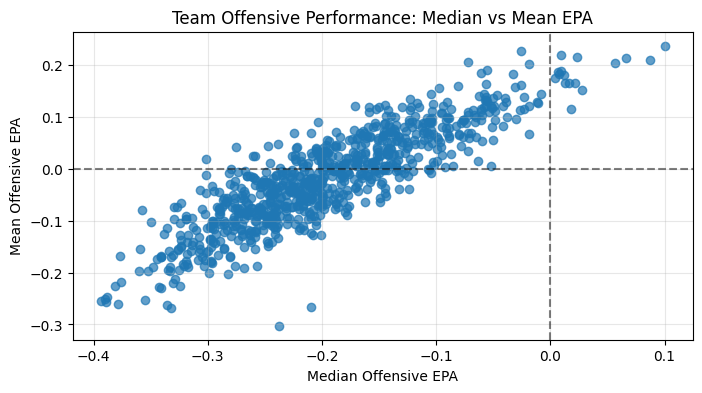

In [49]:
plt.figure(figsize=(8, 4))
offense_plot = plt.scatter(df.median_off_epa, df.mean_off_epa, alpha=0.7)
plt.xlabel('Median Offensive EPA')
plt.ylabel('Mean Offensive EPA')
plt.title('Team Offensive Performance: Median vs Mean EPA')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.show()

Create a chart that shows week by week a defenses performance.

In [65]:
df_games.head()

,game_id,posteam,defteam,season,week,avg_off_epa,avg_def_epa
0,1999_01_BUF_IND,BUF,IND,1999,1,-0.151488,0.151488
1,1999_01_MIN_ATL,None,None,1999,1,NaN,NaN
2,1999_02_ARI_MIA,MIA,ARI,1999,2,-0.165787,0.165787
3,1999_02_ARI_MIA,ARI,MIA,1999,2,-0.179640,0.179640
4,1999_02_NO_SF,SF,NO,1999,2,0.066788,-0.066788


In [110]:
d_games = df_games[df_games.season>=2022].avg_def_epa
o_games = df_games[df_games.season>=2022].avg_off_epa

o_games.quantile(.75)


def print_quantiles(epa_array):
    print("25th percentile: ",epa_array.quantile(.25))
    print("50th percentile: ",epa_array.quantile(.5))
    print("75th percentile: ",epa_array.quantile(.75))

print("defense: \n")
print_quantiles(d_games)

print("\noffense: \n")
print_quantiles(o_games)

defense: 

25th percentile:  -0.0892915162979203
50th percentile:  0.0035408087862013908
75th percentile:  0.11500796252671153

offense: 

25th percentile:  -0.11500796252671153
50th percentile:  -0.0035408087862013908
75th percentile:  0.0892915162979203


<Axes: >

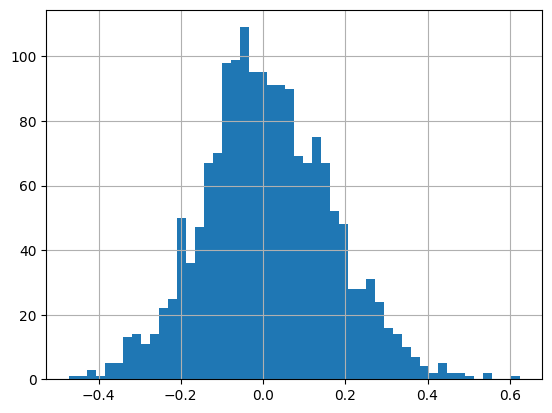

In [109]:
d_games.hist(bins=50)

In [106]:
df_games[df_games['avg_off_epa'] ==0]

,game_id,posteam,defteam,season,week,season_type,avg_off_epa,avg_def_epa
4,2001_15_BUF_ATL,None,None,2001,15,REG,0.0,0.0
5,2001_15_NYJ_IND,None,None,2001,15,REG,0.0,0.0
7,2001_16_ATL_MIA,None,None,2001,16,REG,0.0,0.0
9,2001_16_KC_JAX,None,None,2001,16,REG,0.0,0.0
10,2001_17_ARI_WAS,None,None,2001,17,REG,0.0,0.0
...,...,...,...,...,...,...,...,...
21021,2019_15_CHI_GB,None,None,2019,15,REG,0.0,0.0
21022,2019_15_NE_CIN,None,None,2019,15,REG,0.0,0.0
21023,2019_16_ARI_SEA,None,None,2019,16,REG,0.0,0.0
21024,2019_16_DAL_PHI,None,None,2019,16,REG,0.0,0.0


In [79]:
df.head()

,posteam,season,median_off_epa,mean_off_epa,offense_rating
0,DEN,1999,-0.224647,-0.047676,bad
1,CLE,1999,-0.324529,-0.128422,bad
2,IND,2000,-0.103534,0.111361,good
3,CHI,2001,-0.253548,-0.078087,bad
4,PHI,2001,-0.249879,-0.024855,bad


In [ ]:

bills_d.head()

,game_id,posteam,defteam,season,week,season_type,avg_off_epa,avg_def_epa,median_off_epa,mean_off_epa,offense_rating
0,2023_16_BUF_LAC,LAC,BUF,2023,16,REG,0.008662,-0.008662,-0.231579,-0.075940,bad
1,2022_03_BUF_MIA,MIA,BUF,2022,3,REG,0.097517,-0.097517,-0.204414,0.030147,bad
2,2022_19_MIA_BUF,MIA,BUF,2022,19,POST,-0.154122,0.154122,-0.204414,0.030147,bad
3,2023_01_BUF_NYJ,NYJ,BUF,2023,1,REG,-0.015500,0.015500,-0.390022,-0.251565,bad
4,2023_05_JAX_BUF,JAX,BUF,2023,5,REG,0.142981,-0.142981,-0.216776,-0.070331,bad


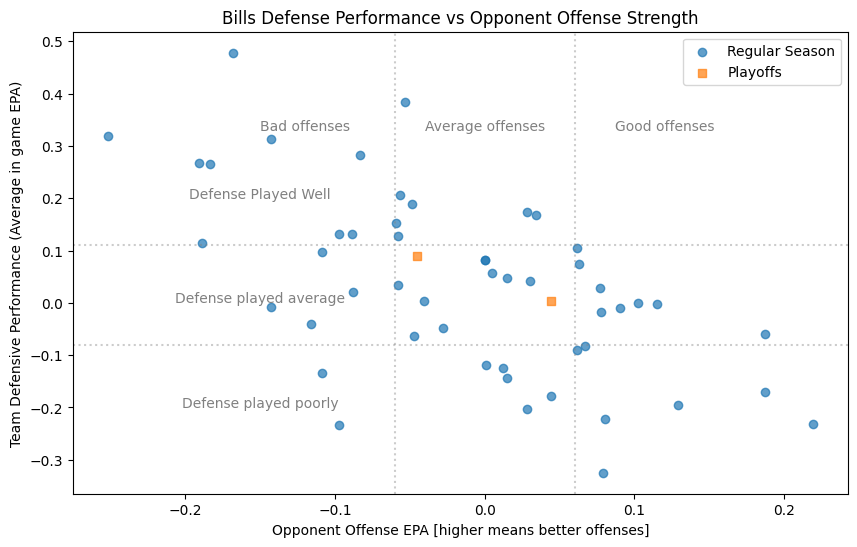

In [156]:
bills_d = df_games[(df_games.defteam=='LAC')&(df_games.season>=2022)].merge(df, on=('posteam','season'),how='left')


plt.figure(figsize=(10, 6))

# Create different markers for regular season vs playoffs
regular_season = bills_d[bills_d.season_type == 'REG']
playoffs = bills_d[bills_d.season_type == 'POST']

# Plot regular season games with circles
plt.scatter(regular_season['mean_off_epa'], regular_season['avg_def_epa'], 
           marker='o', label='Regular Season', alpha=0.7)

# Plot playoff games with squares
plt.scatter(playoffs['mean_off_epa'], playoffs['avg_def_epa'], 
           marker='s', label='Playoffs', alpha=0.7)

plt.xlabel('Opponent Offense EPA [higher means better offenses]')
plt.ylabel('Team Defensive Performance (Average in game EPA)')
plt.title('Bills Defense Performance vs Opponent Offense Strength')
plt.legend()

# Add vertical lines at -0.06 and 0.06
plt.axvline(x=-0.06, color='gray', linestyle=':', alpha=0.4)
plt.axvline(x=0.06, color='gray', linestyle=':', alpha=0.4)

# Add horizontal lines at -0.08 and 0.11
plt.axhline(y=-0.08, color='gray', linestyle=':', alpha=0.4)
plt.axhline(y=0.11, color='gray', linestyle=':', alpha=0.4)

# Add text to top of each grid box
plt.text(-0.12, 0.33, 'Bad offenses', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')
plt.text(0, 0.33, 'Average offenses', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')
plt.text(0.12, 0.33, 'Good offenses', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')

plt.text(-0.15, .2, 'Defense Played Well', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')
plt.text(-0.15, 0, 'Defense played average', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')
plt.text(-0.15, -0.2, 'Defense played poorly', fontsize=plt.rcParams['axes.labelsize'], ha='center', color='gray')

plt.show()